# Neural Network for ECG Classification



all lead ecg ml with resnet model



In [ ]:

import time
time.sleep(1500)  


In [1]:
# # wait for 45*25 seconds
# import time
# time.sleep(1125)

#### IMPORTS

In [2]:
import torchvision
import numpy as np

from dataloader import MyCustomDataset
from torch.utils.data import DataLoader

import torch.nn as nn
import torch.optim as optim

import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [3]:
default_dir = os.getcwd()
def default_directory():
    os.chdir(f"{default_dir}")
    print(f"you are back to the default directory: {default_dir}")


In [4]:
default_directory()
os.getcwd()

you are back to the default directory: /home/karansingh/Documents/summer term/ECG_ML/MAIN


'/home/karansingh/Documents/summer term/ECG_ML/MAIN'

In [5]:
os.chdir("data_prep")
os.getcwd()

'/home/karansingh/Documents/summer term/ECG_ML/MAIN/data_prep'

In [6]:
# get list of all files in the directory
files = os.listdir()
print(files)

['README copy', 'unq_disease_SB.npy', 'disease_SR.npy', 'data_prep.ipynb', 'disease_SB.npy', 'EXPERIMENT_resnet', 'disease_ST.npy', 'unq_disease_SR.npy', 'README.md', 'EXPERIMENT_2', 'data_prep_for_only_one_disease.ipynb', 'EXPERIMENT_resnet_1d', 'unq_disease_ST.npy']


#### LOAD DATA

In [7]:
data_ST_list = np.load("disease_ST.npy")
data_SB_list = np.load("disease_SB.npy")
data_SR_list = np.load("disease_SR.npy")
#print shape of all loaded files
print("shape of ST data: ", data_ST_list.shape)
print("shape of SB data: ", data_SB_list.shape)
print("shape of SR data: ", data_SR_list.shape)

shape of ST data:  (5000, 5000, 12)
shape of SB data:  (5000, 5000, 12)
shape of SR data:  (5000, 5000, 12)


### sanity check

In [8]:
# check the curupted data
def check_data(data):
    corrupted_indices = []
    for i in range(data.shape[0]):
        if np.isnan(data[i]).any() or np.isinf(data[i]).any():
            corrupted_indices.append(i)
    return corrupted_indices
corrupted_ST = check_data(data_ST_list)
corrupted_SB = check_data(data_SB_list)
corrupted_SR = check_data(data_SR_list)
print("corrupted ST indices: ", corrupted_ST)
print("corrupted SB indices: ", corrupted_SB)
print("corrupted SR indices: ", corrupted_SR)


corrupted ST indices:  [2341, 3205, 3257, 3746, 3810, 3837, 3928, 4232, 4302, 4317, 4516, 4533, 4578]
corrupted SB indices:  [3941, 4202, 4212, 4271]
corrupted SR indices:  [1854, 2166, 2256, 2833, 2888, 3212, 3375, 3749, 3817, 3820, 4083, 4236, 4253, 4425, 4875, 4896]


In [9]:
len(corrupted_SR)

16

In [9]:
# now che ck nana and inf difrently
def check_nan_inf(data):
    nan_indices = []
    inf_indices = []
    for i in range(data.shape[0]):
        if np.isnan(data[i]).any():
            nan_indices.append(i)
        if np.isinf(data[i]).any():
            inf_indices.append(i)
    return nan_indices, inf_indices
nan_ST, inf_ST = check_nan_inf(data_ST_list)
nan_SB, inf_SB = check_nan_inf(data_SB_list)
nan_SR, inf_SR = check_nan_inf(data_SR_list)
print("NaN ST indices: ", nan_ST)
print("Inf ST indices: ", inf_ST)
print("NaN SB indices: ", nan_SB)
print("Inf SB indices: ", inf_SB)
print("NaN SR indices: ", nan_SR)
print("Inf SR indices: ", inf_SR)


NaN ST indices:  [2341, 3205, 3257, 3746, 3810, 3837, 3928, 4232, 4302, 4317, 4516, 4533, 4578]
Inf ST indices:  []
NaN SB indices:  [3941, 4202, 4212, 4271]
Inf SB indices:  []
NaN SR indices:  [1854, 2166, 2256, 2833, 2888, 3212, 3375, 3749, 3817, 3820, 4083, 4236, 4253, 4425, 4875, 4896]
Inf SR indices:  []


In [10]:
# Loop over all ST indices with NaNs and summarize locations
nan_summary = {}

for idx in nan_ST:
    sample = data_ST_list[idx]  # shape: (5000, 12)

    # All NaN locations for this sample
    locs = np.argwhere(np.isnan(sample))  # rows, cols
    cols_with_nan = np.unique(locs[:, 1]) if locs.size else np.array([], dtype=int)



    nan_summary[idx] = {
        "count": int(locs.shape[0]),
        "cols": cols_with_nan.tolist()
,
    }

    print(
        f"ST sample {idx}: NaNs={nan_summary[idx]['count']}, "
        f"cols={nan_summary[idx]['cols']}, "
    )

# Optional: access detailed rows for a given sample index, e.g., nan_summary[nan_ST[0]]["rows_in_col"]

ST sample 2341: NaNs=31, cols=[9, 10], 
ST sample 3205: NaNs=26, cols=[11], 
ST sample 3257: NaNs=26, cols=[11], 
ST sample 3746: NaNs=3, cols=[8], 
ST sample 3810: NaNs=64, cols=[7], 
ST sample 3837: NaNs=12, cols=[11], 
ST sample 3928: NaNs=21, cols=[11], 
ST sample 4232: NaNs=3, cols=[11], 
ST sample 4302: NaNs=57, cols=[11], 
ST sample 4317: NaNs=213, cols=[9, 10, 11], 
ST sample 4516: NaNs=68, cols=[8], 
ST sample 4533: NaNs=3, cols=[9], 
ST sample 4578: NaNs=422, cols=[7, 10], 


In [11]:
import numpy as np

# Get the array
data = data_ST_list[nan_ST[-2]]
print(f"Array shape: {data.shape}")

# Find exact NaN locations
nan_locations = np.argwhere(np.isnan(data))

print(f"\nTotal NaN values found: {len(nan_locations)}")
print("\nNaN locations (row, column):")
for row, col in nan_locations:
    print(f"  NaN at row {row}, column {col}")

Array shape: (5000, 12)

Total NaN values found: 3

NaN locations (row, column):
  NaN at row 707, column 9
  NaN at row 723, column 9
  NaN at row 724, column 9


In [12]:
# import numpy as np

# datasets = {
#     "ST": (data_ST_list, nan_ST),
#     "SR": (data_SR_list, nan_SR),
#     "SB": (data_SB_list, nan_SB),
# }

# nan_summary = {}

# for name, (data_list, nan_indices) in datasets.items():
#     for idx in nan_indices:
#         sample = data_list[idx]  # shape: (5000, 12)

#         # All NaN locations
#         locs = np.argwhere(np.isnan(sample))  # (row, col)
#         cols_with_nan = np.unique(locs[:, 1]) if locs.size else np.array([], dtype=int)


#         nan_summary[(name, idx)] = {
#             "count": int(locs.shape[0]),
#             "cols": cols_with_nan.tolist(),
#         }

#         print(
#             f"{name} sample {idx}: NaNs={nan_summary[(name, idx)]['count']}, "
#             f"cols={nan_summary[(name, idx)]['cols']}, "
#         )


In [13]:
# remove corrupted data from all three datasets
def remove_corrupted_data(data_list, corrupted_indices):
    return np.delete(data_list, corrupted_indices, axis=0)
    return cleaned_data

data_ST_list = remove_corrupted_data(data_ST_list, nan_ST + inf_ST)
data_SB_list = remove_corrupted_data(data_SB_list, nan_SB + inf_SB)
data_SR_list = remove_corrupted_data(data_SR_list, nan_SR + inf_SR)

### creating batches


In [14]:

# lead 1
# Use ALL 12 leads
images = data_ST_list          # shape: (N_ST, T, 12)
labels = np.zeros(images.shape[0])

# SB
images = np.concatenate((images, data_SB_list), axis=0)
labels = np.concatenate((labels, np.ones(data_SB_list.shape[0])))

# SR
images = np.concatenate((images, data_SR_list), axis=0)
labels = np.concatenate((labels, 2*np.ones(data_SR_list.shape[0])))

print("we have", images.shape[0], "samples and", labels.shape[0], "labels")
print("raw shape:", images.shape)

                    

we have 14967 samples and 14967 labels
raw shape: (14967, 5000, 12)


In [15]:
len(images),len(labels)

(14967, 14967)

In [16]:
from sklearn.model_selection import train_test_split

X = images        # (12965, 5000, 12)
y = labels      # (12965,)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

#split is of 70% train, 15% val, 15% test


In [17]:
# compute stats on TRAIN set only
mean = X_train.mean(axis=(0, 1))   # (12,)
std  = X_train.std(axis=(0, 1))    # (12,)

std[std < 1e-6] = 1e-6  # safety


In [18]:
# apply normalization
X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std


#### transposing data

In [19]:
# (batch, time, channels) → (batch, channels, time)
X_train = X_train.transpose(0, 2, 1)
X_val   = X_val.transpose(0, 2, 1)
X_test  = X_test.transpose(0, 2, 1)


In [20]:
import torch
from torch.utils.data import TensorDataset, DataLoader

train_ds = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)

val_ds = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)

test_ds = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)

train_dataloader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dataloader   = DataLoader(val_ds, batch_size=32, shuffle=False)
test_dataloader  = DataLoader(test_ds, batch_size=32, shuffle=False)

#### CREATE BATCHES

In [21]:
# # 70% train, 15% val, 15% test split
# images_train, images_temp, labels_train, labels_temp = train_test_split(
#     images, labels, train_size=0.70, random_state=42
# )
# images_val, images_test, labels_val, labels_test = train_test_split(
#     images_temp, labels_temp, test_size=0.5, random_state=42
# )

# train_dataset = MyCustomDataset_resnet(images_train, labels_train)
# val_dataset   = MyCustomDataset_resnet(images_val, labels_val)
# test_dataset  = MyCustomDataset_resnet(images_test, labels_test)

# train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# val_dataloader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
# test_dataloader  = DataLoader(test_dataset, batch_size=32, shuffle=False)


## model


### resnet model

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=7, stride=1):
        super().__init__()
        padding = kernel_size // 2

        self.conv1 = nn.Conv1d(in_channels, out_channels,
                               kernel_size, stride, padding, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(out_channels, out_channels,
                               kernel_size, 1, padding, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)
class ResNet1D(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.layer1 = ResidualBlock1D(12, 64)
        self.layer2 = ResidualBlock1D(64, 128, stride=2)
        self.layer3 = ResidualBlock1D(128, 256, stride=2)

        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.global_pool(x)
        x = x.squeeze(-1)
        return self.fc(x)



#### TRAINING PARAMETERS

In [23]:
torch.manual_seed(37)  # Set seed for reproducibility
model = ResNet1D()

criterion = nn.CrossEntropyLoss()  # Cross-entropy loss for classification
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam optimizer
def accuracy(y_true, y_pred):
    """Calculates accuracy between truth labels and predictions.

    Args:
        y_true (torch.Tensor): Truth labels for predictions.
        y_pred (torch.Tensor): Predictions to be compared to predictions.

    Returns:
        [torch.float]: Accuracy value between y_true and y_pred, e.g. 78.45
    """
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc


#### TRAINING

#### resnettorch vision


In [24]:
import torch
import torch.nn as nn
import torchvision.models as models

# Modified ResNet18 for ECG
class ECGResNet(nn.Module):
    def __init__(self, num_classes=3, pretrained=True):
        super(ECGResNet, self).__init__()
        
        # Load pretrained ResNet18
        resnet = models.resnet18(pretrained=pretrained)
        
        # Modify first conv layer: 1 input channel instead of 3 (RGB)
        # Keep pretrained weights by averaging across RGB channels
        self.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        if pretrained:
            # Average the pretrained RGB weights to single channel
            self.conv1.weight.data = resnet.conv1.weight.data.mean(dim=1, keepdim=True)
        
        # Copy other layers from ResNet18
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4
        self.avgpool = resnet.avgpool
        
        # Modify final fully connected layer for 3 classes
        self.fc = nn.Linear(resnet.fc.in_features, num_classes)
    
    def forward(self, x):
        # x shape: (batch, 12, 5000)
        # Add channel dimension: (batch, 1, 12, 5000)
        x = x.unsqueeze(1)
        
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x



In [25]:
import copy
import torch
import torch.nn as nn
import numpy as np
import os
import time
from datetime import datetime
from IPython.display import clear_output
default_directory()
#import smallcnn
namkaran = "resnet_lr1e-3"


# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# === Settings ===
num_epochs, patience = 25, 7

# Get the notebook name
try:
    from IPython import get_ipython
    notebook_name = get_ipython().user_ns.get('__vsc_ipynb_file__', None)
    if notebook_name is None:
        import ipynbname
        notebook_name = ipynbname.name()
    notebook_name = os.path.splitext(os.path.basename(notebook_name))[0]
except:
    notebook_name = "image_resnet_type_2"

log_dir = "EXPERIMENT_resnet_1d_typ2"
os.makedirs(log_dir, exist_ok=True)
log_path = os.path.join(log_dir, f"{notebook_name}_{namkaran}.txt")

# Utility function to log both to console and file
def log_print(msg, f):
    print(msg)
    f.write(msg + "\n")
    f.flush()

clear_output(wait=True)
with open(log_path, "a") as f:
    log_print("\n" + "="*60, f)
    log_print(f"Training Run Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}", f)
    log_print("="*60, f)

    model = ECGResNet().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2
    )

    def correct(pred, true):
        return (pred == true).sum().item()

    train_losses_list, val_losses_list = [], []
    accuracy_train_list, accuracy_val_list = [], []
    best_acc, wait, best_model = 0, 0, None

    # Start total training timer
    total_start_time = time.time()

    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        
        # --- Train ---
        model.train()
        run_loss = 0
        c_train = t_train = 0
        train_start_time = time.time()
        
        for x, y in train_dataloader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            run_loss += loss.item()
            c_train += correct(out.argmax(1), y)
            t_train += y.size(0)

        train_time = time.time() - train_start_time
        train_losses_list.append(run_loss / len(train_dataloader))
        accuracy_train_list.append(100 * c_train / t_train)

        # --- Validation ---
        model.eval()
        run_loss = 0
        c_val = t_val = 0
        val_start_time = time.time()
        
        with torch.no_grad():
            for x, y in val_dataloader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                run_loss += loss.item()
                c_val += correct(out.argmax(1), y)
                t_val += y.size(0)

        val_time = time.time() - val_start_time
        val_losses_list.append(run_loss / len(val_dataloader))
        accuracy_val_list.append(100 * c_val / t_val)

        # --- LR scheduler ---
        old_lr = optimizer.param_groups[0]["lr"]
        scheduler.step(val_losses_list[-1])
        lr_now = optimizer.param_groups[0]["lr"]
        
        # Manual verbose logging
        if lr_now != old_lr:
            log_print(f"  >> Learning rate reduced: {old_lr:.6f} -> {lr_now:.6f}", f)

        # --- Early stopping ---
        if accuracy_val_list[-1] > best_acc:
            best_acc, wait = accuracy_val_list[-1], 0
            best_model = copy.deepcopy(model.state_dict())
        else:
            wait += 1
            if wait >= patience:
                log_print(f"## Early stopping at epoch {epoch + 1} ##", f)
                break

        epoch_time = time.time() - epoch_start_time
        
        log_print(
            f"Epoch [{epoch + 1}/{num_epochs}] | "
            f"Train Loss: {train_losses_list[-1]:.4f}, Val Loss: {val_losses_list[-1]:.4f}, "
            f"Train Acc: {accuracy_train_list[-1]:.2f}%, Val Acc: {accuracy_val_list[-1]:.2f}%, "
            f"LR: {lr_now:.6f} | "
            f"Time: {epoch_time:.2f}s (Train: {train_time:.2f}s, Val: {val_time:.2f}s)",
            f,
        )

    total_training_time = time.time() - total_start_time

    # Restore best weights and save
    model.load_state_dict(best_model)
    torch.save(best_model, os.path.join(log_dir, f"{notebook_name}_{namkaran}.pth"))
    log_print(f"\nBest Validation Accuracy: {best_acc:.2f}%", f)

    # --- Test accuracy ---
    model.eval()
    c_test = t_test = 0
    test_start_time = time.time()
    
    with torch.no_grad():
        for x, y in test_dataloader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            c_test += correct(out.argmax(1), y)
            t_test += y.size(0)
    
    test_time = time.time() - test_start_time
    test_acc = 100 * c_test / t_test
    log_print(f"Test Accuracy: {test_acc:.2f}% (Time: {test_time:.2f}s)", f)
    
    log_print("="*60, f)
    log_print(f"Total Training Time: {total_training_time:.2f}s ({total_training_time/60:.2f} minutes)", f)
    log_print("✅ Training complete.", f)

    


Training Run Started: 2026-01-18 21:16:01


/home/karansingh/Documents/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/karansingh/Documents/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/25] | Train Loss: 0.3141, Val Loss: 0.2086, Train Acc: 88.06%, Val Acc: 92.25%, LR: 0.001000 | Time: 57.67s (Train: 54.20s, Val: 3.47s)
Epoch [2/25] | Train Loss: 0.1897, Val Loss: 0.1555, Train Acc: 93.38%, Val Acc: 95.55%, LR: 0.001000 | Time: 57.79s (Train: 54.32s, Val: 3.47s)
Epoch [3/25] | Train Loss: 0.1601, Val Loss: 0.1420, Train Acc: 94.66%, Val Acc: 95.14%, LR: 0.001000 | Time: 57.80s (Train: 54.36s, Val: 3.44s)
Epoch [4/25] | Train Loss: 0.1443, Val Loss: 0.1431, Train Acc: 94.88%, Val Acc: 95.10%, LR: 0.001000 | Time: 57.92s (Train: 54.46s, Val: 3.46s)
Epoch [5/25] | Train Loss: 0.1490, Val Loss: 0.1169, Train Acc: 94.83%, Val Acc: 96.57%, LR: 0.001000 | Time: 58.04s (Train: 54.56s, Val: 3.48s)
Epoch [6/25] | Train Loss: 0.1298, Val Loss: 0.1168, Train Acc: 95.34%, Val Acc: 96.57%, LR: 0.001000 | Time: 58.05s (Train: 54.57s, Val: 3.48s)
Epoch [7/25] | Train Loss: 0.1287, Val Loss: 0.1073, Train Acc: 95.62%, Val Acc: 96.79%, LR: 0.001000 | Time: 58.04s (Train: 54.57

you are back to the default directory: /home/karansingh/Documents/summer term/ECG_ML/MAIN
CONFUSION MATRIX


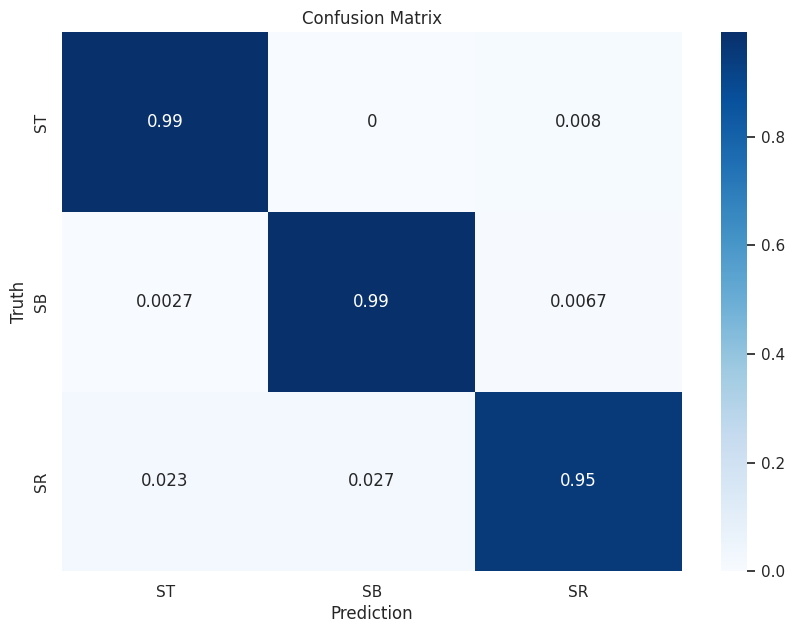


MICRO-AVERAGED PRECISION-RECALL CURVE
Average precision score, micro-averaged over all classes: 0.99


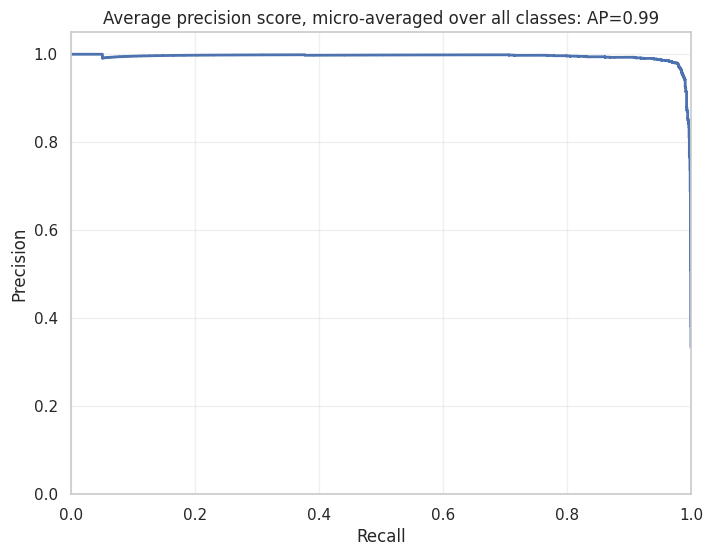


PER-CLASS PRECISION-RECALL CURVES


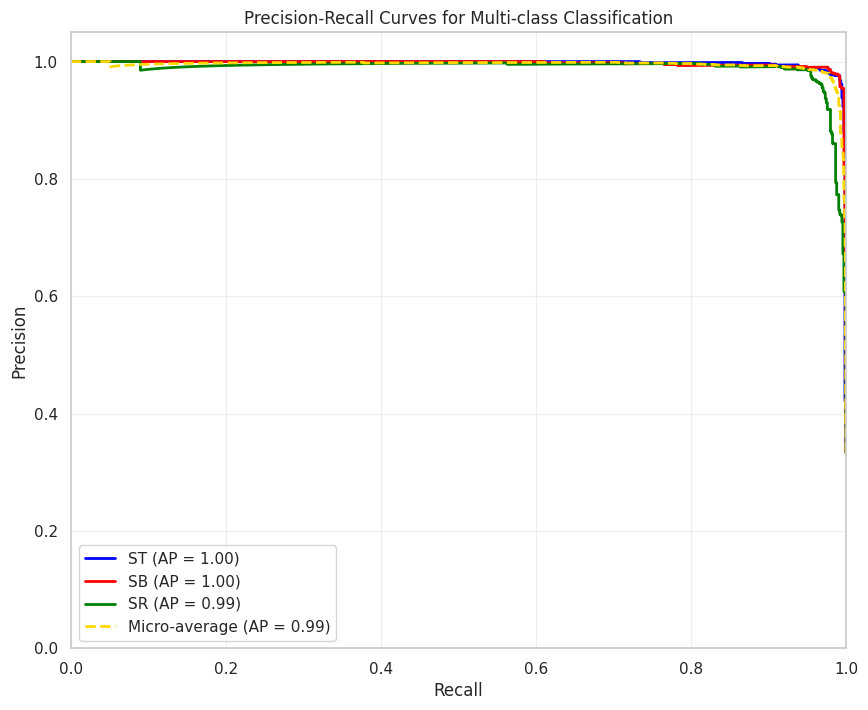


ROC CURVES


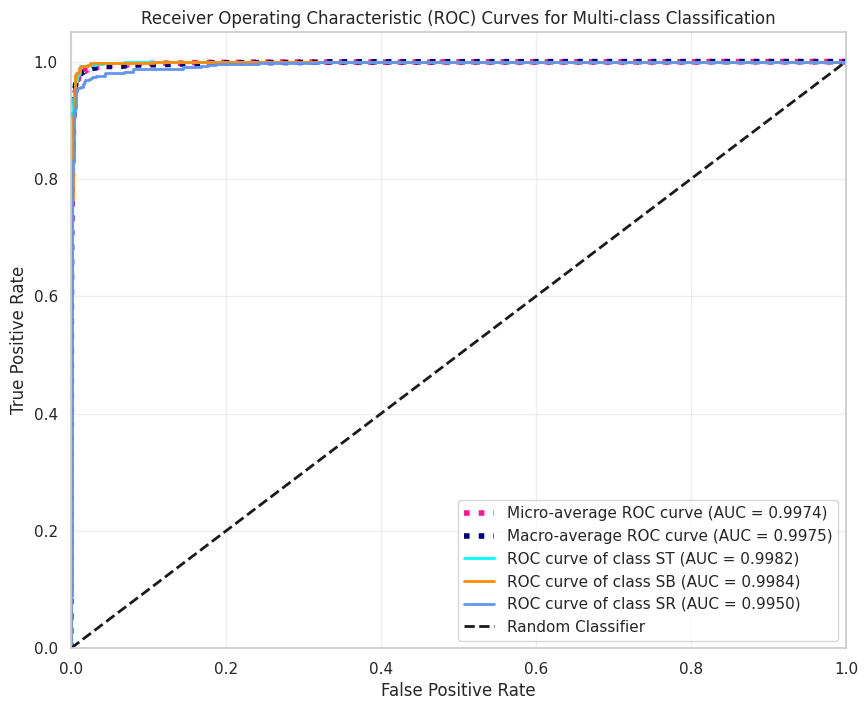

AUC Scores:
Class ST: 0.9982
Class SB: 0.9984
Class SR: 0.9950
Micro-average: 0.9974
Macro-average: 0.9975

CLASSIFICATION REPORT
              precision    recall  f1-score   support

          ST     0.9750    0.9920    0.9834       748
          SB     0.9738    0.9907    0.9822       750
          SR     0.9848    0.9505    0.9673       748

    accuracy                         0.9777      2246
   macro avg     0.9779    0.9777    0.9776      2246
weighted avg     0.9779    0.9777    0.9776      2246


EVALUATION COMPLETE
you are back to the default directory: /home/karansingh/Documents/summer term/ECG_ML/MAIN


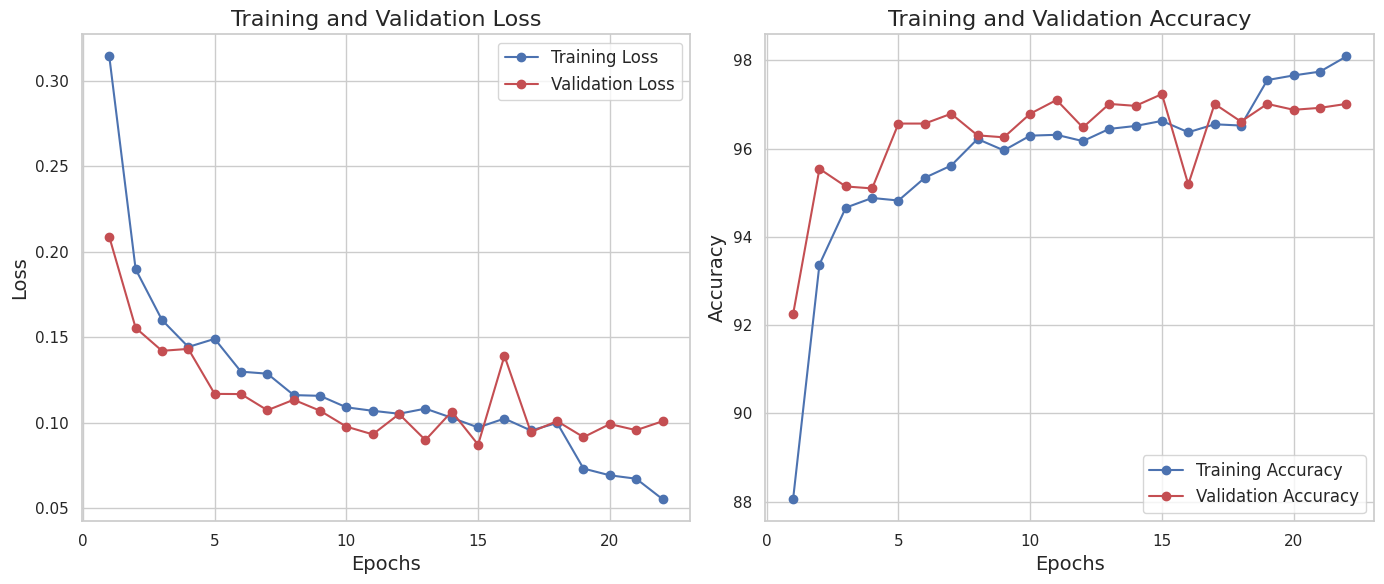

In [27]:
default_directory()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
from plots import evaluate_all
# Selective plotting
results = evaluate_all(
    model, test_dataloader, device,
    plot_confusion_matrix=True,
    plot_pr_micro=True,
    plot_pr_per_class=True,
    plot_roc=True,
    print_report=True
)

default_directory()
from plots import accuracy_and_validation_plots


# Example data: Replace these with your actual training and validation data
epochs_= list(range(1, len(train_losses_list)+1))

accuracy_and_validation_plots(epochs_, train_losses_list, val_losses_list, accuracy_train_list,accuracy_val_list).plot_figure("accuracy.png")


# ignore

In [ ]:
import copy
import torch
import torch.nn as nn
import numpy as np
import os
import time
from datetime import datetime
from IPython.display import clear_output
default_directory()
#import smallcnn
namkaran = "version_2_small_cnn_lr1e-3"


# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# === Settings ===
num_epochs, patience = 25, 7

# Get the notebook name
try:
    from IPython import get_ipython
    notebook_name = get_ipython().user_ns.get('__vsc_ipynb_file__', None)
    if notebook_name is None:
        import ipynbname
        notebook_name = ipynbname.name()
    notebook_name = os.path.splitext(os.path.basename(notebook_name))[0]
except:
    notebook_name = "image_resnet_type_1"

log_dir = "EXPERIMENT_resnet_image"
os.makedirs(log_dir, exist_ok=True)
log_path = os.path.join(log_dir, f"{notebook_name}_{namkaran}.txt")

# Utility function to log both to console and file
def log_print(msg, f):
    print(msg)
    f.write(msg + "\n")
    f.flush()

clear_output(wait=True)
with open(log_path, "a") as f:
    log_print("\n" + "="*60, f)
    log_print(f"Training Run Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}", f)
    log_print("="*60, f)

    model = SmallCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2
    )

    def correct(pred, true):
        return (pred == true).sum().item()

    train_losses_list, val_losses_list = [], []
    accuracy_train_list, accuracy_val_list = [], []
    best_acc, wait, best_model = 0, 0, None

    # Start total training timer
    total_start_time = time.time()

    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        
        # --- Train ---
        model.train()
        run_loss = 0
        c_train = t_train = 0
        train_start_time = time.time()
        
        for x, y in train_dataloader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            run_loss += loss.item()
            c_train += correct(out.argmax(1), y)
            t_train += y.size(0)

        train_time = time.time() - train_start_time
        train_losses_list.append(run_loss / len(train_dataloader))
        accuracy_train_list.append(100 * c_train / t_train)

        # --- Validation ---
        model.eval()
        run_loss = 0
        c_val = t_val = 0
        val_start_time = time.time()
        
        with torch.no_grad():
            for x, y in val_dataloader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                run_loss += loss.item()
                c_val += correct(out.argmax(1), y)
                t_val += y.size(0)

        val_time = time.time() - val_start_time
        val_losses_list.append(run_loss / len(val_dataloader))
        accuracy_val_list.append(100 * c_val / t_val)

        # --- LR scheduler ---
        old_lr = optimizer.param_groups[0]["lr"]
        scheduler.step(val_losses_list[-1])
        lr_now = optimizer.param_groups[0]["lr"]
        
        # Manual verbose logging
        if lr_now != old_lr:
            log_print(f"  >> Learning rate reduced: {old_lr:.6f} -> {lr_now:.6f}", f)

        # --- Early stopping ---
        if accuracy_val_list[-1] > best_acc:
            best_acc, wait = accuracy_val_list[-1], 0
            best_model = copy.deepcopy(model.state_dict())
        else:
            wait += 1
            if wait >= patience:
                log_print(f"## Early stopping at epoch {epoch + 1} ##", f)
                break

        epoch_time = time.time() - epoch_start_time
        
        log_print(
            f"Epoch [{epoch + 1}/{num_epochs}] | "
            f"Train Loss: {train_losses_list[-1]:.4f}, Val Loss: {val_losses_list[-1]:.4f}, "
            f"Train Acc: {accuracy_train_list[-1]:.2f}%, Val Acc: {accuracy_val_list[-1]:.2f}%, "
            f"LR: {lr_now:.6f} | "
            f"Time: {epoch_time:.2f}s (Train: {train_time:.2f}s, Val: {val_time:.2f}s)",
            f,
        )

    total_training_time = time.time() - total_start_time

    # Restore best weights and save
    model.load_state_dict(best_model)
    torch.save(best_model, os.path.join(log_dir, f"{notebook_name}_{namkaran}.pth"))
    log_print(f"\nBest Validation Accuracy: {best_acc:.2f}%", f)

    # --- Test accuracy ---
    model.eval()
    c_test = t_test = 0
    test_start_time = time.time()
    
    with torch.no_grad():
        for x, y in test_dataloader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            c_test += correct(out.argmax(1), y)
            t_test += y.size(0)
    
    test_time = time.time() - test_start_time
    test_acc = 100 * c_test / t_test
    log_print(f"Test Accuracy: {test_acc:.2f}% (Time: {test_time:.2f}s)", f)
    
    log_print("="*60, f)
    log_print(f"Total Training Time: {total_training_time:.2f}s ({total_training_time/60:.2f} minutes)", f)
    log_print("✅ Training complete.", f)

    

In [ ]:
print("Label min:", labels.min())
print("Label max:", labels.max())
print("Label dtype:", labels.dtype)


In [ ]:
# # === Instantiate a new model object ===
# model = model().to(device)

# # === Load the best saved state dict ===
# model.load_state_dict(best_model_state)

# === Set to evaluation mode ===
model.eval()

# print(f"Loaded best model from seed {best_seed} with accuracy {best_acc_overall:.2f}")


In [ ]:
default_directory()
from plots import accuracy_and_validation_plots


# Example data: Replace these with your actual training and validation data
epochs_= list(range(1, len(train_losses_list)+1))

accuracy_and_validation_plots(epochs_, train_losses_list, val_losses_list, accuracy_train_list,accuracy_val_list).plot_figure("accuracy.png")


In [ ]:
#confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd
import torch.nn.functional as F

model.eval()
y_pred = []
y_true = []
y_scores = []  # Added to collect probability scores

with torch.no_grad():
    for images, labels in test_dataloader:
        outputs = model(images.to(device))
        # Get probability scores using softmax
        probabilities = F.softmax(outputs, dim=1)
        y_scores.extend(probabilities.cpu().numpy())
        
        _, predicted = torch.max(outputs, 1)
        y_pred.extend(predicted.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

# Convert to numpy arrays
y_scores = np.array(y_scores)

cm = confusion_matrix(y_true, y_pred)
cm = cm / cm.sum(axis=1)[:, np.newaxis]  # Normalize confusion matrix
df_cm = pd.DataFrame(cm, index=["ST", "SB", "SR"], columns=["ST", "SB", "SR"])
plt.figure(figsize=(10, 7))
sns.heatmap(df_cm, annot=True, cmap='Blues')
plt.xlabel('Prediction')
plt.ylabel('Truth')
plt.title('Confusion Matrix')
plt.show()

In [ ]:

#Classification Report for Test Data:

from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=["ST", "SB", "SR"]))


In [ ]:
# Precision-Recall Curve
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt

# Compute Precision-Recall and plot curve
precision = dict()
recall = dict()
average_precision = dict()

# For each class, compute PR curve using probability scores
for i in range(3):
    precision[i], recall[i], _ = precision_recall_curve(
        (np.array(y_true) == i).astype(int),  # Binary true labels for class i
        y_scores[:, i]  # Probability scores for class i
    )
    average_precision[i] = average_precision_score(
        (np.array(y_true) == i).astype(int), 
        y_scores[:, i]
    )

# Micro-average: using probability scores
from sklearn.preprocessing import label_binarize
y_true_binary = label_binarize(y_true, classes=[0, 1, 2])

precision["micro"], recall["micro"], _ = precision_recall_curve(
    y_true_binary.ravel(),
    y_scores.ravel()
)
average_precision["micro"] = average_precision_score(
    y_true_binary, 
    y_scores,
    average="micro"
)

print('Average precision score, micro-averaged over all classes: {0:0.2f}'
        .format(average_precision["micro"]))

# Plot micro-average PR curve
plt.figure(figsize=(8, 6))
plt.step(recall['micro'], precision['micro'], where='post', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title(
    'Average precision score, micro-averaged over all classes: AP={0:0.2f}'
    .format(average_precision["micro"]))
plt.grid(True, alpha=0.3)
plt.show()

# Plot individual class PR curves
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']
class_names = ['ST', 'SB', 'SR']

for i, color, class_name in zip(range(3), colors, class_names):
    plt.plot(recall[i], precision[i], color=color, lw=2,
             label=f'{class_name} (AP = {average_precision[i]:0.2f})')

plt.plot(recall['micro'], precision['micro'], color='gold', lw=2, linestyle='--',
         label=f'Micro-average (AP = {average_precision["micro"]:0.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-Recall Curves for Multi-class Classification')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# ROC curve
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

# Binarize the true labels for multi-class ROC
y_test = label_binarize(y_true, classes=[0, 1, 2])
# Use probability scores (not predictions!)
y_score = y_scores  # This contains the probability scores from softmax

n_classes = 3

fpr = dict()
tpr = dict()
roc_auc = dict()

# Compute ROC curve and ROC area for each class
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Compute macro-average ROC curve and ROC area
# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Then interpolate all ROC curves at these points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Finally average it and compute AUC
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot all ROC curves
plt.figure(figsize=(10, 8))

# Plot micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"],
         label='Micro-average ROC curve (AUC = {0:0.2f})'
               ''.format(roc_auc["micro"]),
         color='deeppink', linestyle=':', linewidth=4)

# Plot macro-average ROC curve
plt.plot(fpr["macro"], tpr["macro"],
         label='Macro-average ROC curve (AUC = {0:0.2f})'
               ''.format(roc_auc["macro"]),
         color='navy', linestyle=':', linewidth=4)

# Plot ROC curve for each class
colors = ['aqua', 'darkorange', 'cornflowerblue']
class_names = ['ST', 'SB', 'SR']

for i, color, class_name in zip(range(n_classes), colors, class_names):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {class_name} (AUC = {roc_auc[i]:0.2f})')

# Plot diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves for Multi-class Classification')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# Print AUC scores
print("AUC Scores:")
for i, class_name in enumerate(['ST', 'SB', 'SR']):
    print(f"Class {class_name}: {roc_auc[i]:.3f}")
print(f"Micro-average: {roc_auc['micro']:.3f}")
print(f"Macro-average: {roc_auc['macro']:.3f}")

In [ ]:
import copy
import torch
import torch.nn as nn
import numpy as np
import os
import time
from datetime import datetime
from IPython.display import clear_output
default_directory()

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# === Settings ===
num_epochs, patience = 25, 7

# Get the notebook name
try:
    from IPython import get_ipython
    notebook_name = get_ipython().user_ns.get('__vsc_ipynb_file__', None)
    if notebook_name is None:
        import ipynbname
        notebook_name = ipynbname.name()
    notebook_name = os.path.splitext(os.path.basename(notebook_name))[0]
except:
    notebook_name = "image_resnet_type_1"

log_dir = "EXPERIMENT_resnet_1d"
os.makedirs(log_dir, exist_ok=True)
log_path = os.path.join(log_dir, f"{notebook_name}_pretrained_false.txt")

# Utility function to log both to console and file
def log_print(msg, f):
    print(msg)
    f.write(msg + "\n")
    f.flush()

clear_output(wait=True)
with open(log_path, "a") as f:
    log_print("\n" + "="*60, f)
    log_print(f"Training Run Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}", f)
    log_print("="*60, f)

    model = ECGResNet(num_classes=3, pretrained=False).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2
    )

    def correct(pred, true):
        return (pred == true).sum().item()

    train_losses_list, val_losses_list = [], []
    accuracy_train_list, accuracy_val_list = [], []
    best_acc, wait, best_model = 0, 0, None

    # Start total training timer
    total_start_time = time.time()

    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        
        # --- Train ---
        model.train()
        run_loss = 0
        c_train = t_train = 0
        train_start_time = time.time()
        
        for x, y in train_dataloader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            run_loss += loss.item()
            c_train += correct(out.argmax(1), y)
            t_train += y.size(0)

        train_time = time.time() - train_start_time
        train_losses_list.append(run_loss / len(train_dataloader))
        accuracy_train_list.append(100 * c_train / t_train)

        # --- Validation ---
        model.eval()
        run_loss = 0
        c_val = t_val = 0
        val_start_time = time.time()
        
        with torch.no_grad():
            for x, y in val_dataloader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                run_loss += loss.item()
                c_val += correct(out.argmax(1), y)
                t_val += y.size(0)

        val_time = time.time() - val_start_time
        val_losses_list.append(run_loss / len(val_dataloader))
        accuracy_val_list.append(100 * c_val / t_val)

        # --- LR scheduler ---
        old_lr = optimizer.param_groups[0]["lr"]
        scheduler.step(val_losses_list[-1])
        lr_now = optimizer.param_groups[0]["lr"]
        
        # Manual verbose logging
        if lr_now != old_lr:
            log_print(f"  >> Learning rate reduced: {old_lr:.6f} -> {lr_now:.6f}", f)

        # --- Early stopping ---
        if accuracy_val_list[-1] > best_acc:
            best_acc, wait = accuracy_val_list[-1], 0
            best_model = copy.deepcopy(model.state_dict())
        else:
            wait += 1
            if wait >= patience:
                log_print(f"## Early stopping at epoch {epoch + 1} ##", f)
                break

        epoch_time = time.time() - epoch_start_time
        
        log_print(
            f"Epoch [{epoch + 1}/{num_epochs}] | "
            f"Train Loss: {train_losses_list[-1]:.4f}, Val Loss: {val_losses_list[-1]:.4f}, "
            f"Train Acc: {accuracy_train_list[-1]:.2f}%, Val Acc: {accuracy_val_list[-1]:.2f}%, "
            f"LR: {lr_now:.6f} | "
            f"Time: {epoch_time:.2f}s (Train: {train_time:.2f}s, Val: {val_time:.2f}s)",
            f,
        )

    total_training_time = time.time() - total_start_time

    # Restore best weights and save
    model.load_state_dict(best_model)
    torch.save(best_model, os.path.join(log_dir, f"{notebook_name}pretrained_false.pth"))
    log_print(f"\nBest Validation Accuracy: {best_acc:.2f}%", f)

    # --- Test accuracy ---
    model.eval()
    c_test = t_test = 0
    test_start_time = time.time()
    
    with torch.no_grad():
        for x, y in test_dataloader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            c_test += correct(out.argmax(1), y)
            t_test += y.size(0)
    
    test_time = time.time() - test_start_time
    test_acc = 100 * c_test / t_test
    log_print(f"Test Accuracy: {test_acc:.2f}% (Time: {test_time:.2f}s)", f)
    
    log_print("="*60, f)
    log_print(f"Total Training Time: {total_training_time:.2f}s ({total_training_time/60:.2f} minutes)", f)
    log_print("✅ Training complete.", f)

In [ ]:
default_directory()
from plots import accuracy_and_validation_plots


# Example data: Replace these with your actual training and validation data
epochs_= list(range(1, len(train_losses_list)+1))

accuracy_and_validation_plots(epochs_, train_losses_list, val_losses_list, accuracy_train_list,accuracy_val_list).plot_figure("accuracy.png")


In [ ]:
#confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd
import torch.nn.functional as F

model.eval()
y_pred = []
y_true = []
y_scores = []  # Added to collect probability scores

with torch.no_grad():
    for images, labels in test_dataloader:
        outputs = model(images.to(device))
        # Get probability scores using softmax
        probabilities = F.softmax(outputs, dim=1)
        y_scores.extend(probabilities.cpu().numpy())
        
        _, predicted = torch.max(outputs, 1)
        y_pred.extend(predicted.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

# Convert to numpy arrays
y_scores = np.array(y_scores)

cm = confusion_matrix(y_true, y_pred)
cm = cm / cm.sum(axis=1)[:, np.newaxis]  # Normalize confusion matrix
df_cm = pd.DataFrame(cm, index=["ST", "SB", "SR"], columns=["ST", "SB", "SR"])
plt.figure(figsize=(10, 7))
sns.heatmap(df_cm, annot=True, cmap='Blues')
plt.xlabel('Prediction')
plt.ylabel('Truth')
plt.title('Confusion Matrix')
plt.show()

In [ ]:

#Classification Report for Test Data:

from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=["ST", "SB", "SR"]))


In [ ]:
# Precision-Recall Curve
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt

# Compute Precision-Recall and plot curve
precision = dict()
recall = dict()
average_precision = dict()

# For each class, compute PR curve using probability scores
for i in range(3):
    precision[i], recall[i], _ = precision_recall_curve(
        (np.array(y_true) == i).astype(int),  # Binary true labels for class i
        y_scores[:, i]  # Probability scores for class i
    )
    average_precision[i] = average_precision_score(
        (np.array(y_true) == i).astype(int), 
        y_scores[:, i]
    )

# Micro-average: using probability scores
from sklearn.preprocessing import label_binarize
y_true_binary = label_binarize(y_true, classes=[0, 1, 2])

precision["micro"], recall["micro"], _ = precision_recall_curve(
    y_true_binary.ravel(),
    y_scores.ravel()
)
average_precision["micro"] = average_precision_score(
    y_true_binary, 
    y_scores,
    average="micro"
)

print('Average precision score, micro-averaged over all classes: {0:0.2f}'
        .format(average_precision["micro"]))

# Plot micro-average PR curve
plt.figure(figsize=(8, 6))
plt.step(recall['micro'], precision['micro'], where='post', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title(
    'Average precision score, micro-averaged over all classes: AP={0:0.2f}'
    .format(average_precision["micro"]))
plt.grid(True, alpha=0.3)
plt.show()

# Plot individual class PR curves
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']
class_names = ['ST', 'SB', 'SR']

for i, color, class_name in zip(range(3), colors, class_names):
    plt.plot(recall[i], precision[i], color=color, lw=2,
             label=f'{class_name} (AP = {average_precision[i]:0.2f})')

plt.plot(recall['micro'], precision['micro'], color='gold', lw=2, linestyle='--',
         label=f'Micro-average (AP = {average_precision["micro"]:0.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-Recall Curves for Multi-class Classification')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# ROC curve
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

# Binarize the true labels for multi-class ROC
y_test = label_binarize(y_true, classes=[0, 1, 2])
# Use probability scores (not predictions!)
y_score = y_scores  # This contains the probability scores from softmax

n_classes = 3

fpr = dict()
tpr = dict()
roc_auc = dict()

# Compute ROC curve and ROC area for each class
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Compute macro-average ROC curve and ROC area
# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Then interpolate all ROC curves at these points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Finally average it and compute AUC
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot all ROC curves
plt.figure(figsize=(10, 8))

# Plot micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"],
         label='Micro-average ROC curve (AUC = {0:0.2f})'
               ''.format(roc_auc["micro"]),
         color='deeppink', linestyle=':', linewidth=4)

# Plot macro-average ROC curve
plt.plot(fpr["macro"], tpr["macro"],
         label='Macro-average ROC curve (AUC = {0:0.2f})'
               ''.format(roc_auc["macro"]),
         color='navy', linestyle=':', linewidth=4)

# Plot ROC curve for each class
colors = ['aqua', 'darkorange', 'cornflowerblue']
class_names = ['ST', 'SB', 'SR']

for i, color, class_name in zip(range(n_classes), colors, class_names):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {class_name} (AUC = {roc_auc[i]:0.2f})')

# Plot diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves for Multi-class Classification')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# Print AUC scores
print("AUC Scores:")
for i, class_name in enumerate(['ST', 'SB', 'SR']):
    print(f"Class {class_name}: {roc_auc[i]:.3f}")
print(f"Micro-average: {roc_auc['micro']:.3f}")
print(f"Macro-average: {roc_auc['macro']:.3f}")